In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,confusion_matrix

In [2]:
data = pd.read_csv("loan approval data.csv").copy()

# Handle Missing Values

In [3]:
cat_cols = data.select_dtypes(include=["object"]).columns
num_cols = data.select_dtypes(include=["number"]).columns

In [4]:
num_imp = SimpleImputer(strategy="mean")
data[num_cols] = num_imp.fit_transform(data[num_cols])

In [5]:
cat_imp = SimpleImputer(strategy="most_frequent")
data[cat_cols] = cat_imp.fit_transform(data[cat_cols])

# EDA- Exploratory data Analysis

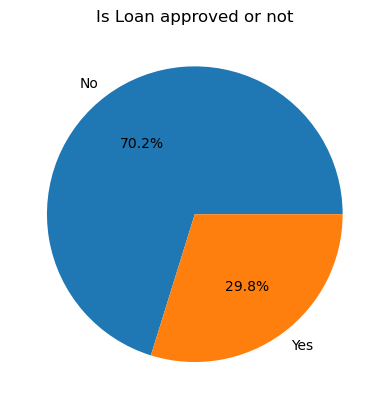

In [6]:
# how balance our classes are:
classes_cont = data["Loan_Approved"].value_counts()
plt.pie(classes_cont, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not")
plt.show()

[Text(0, 0, '621'), Text(0, 0, '379')]

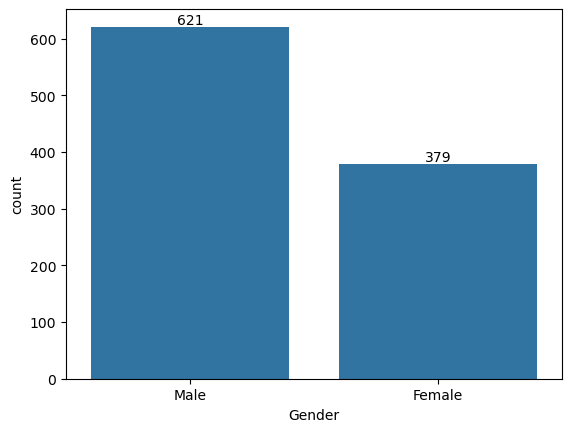

In [7]:
# categorical plot
cat_cnt = data["Gender"].value_counts()
ax = sns.barplot(cat_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

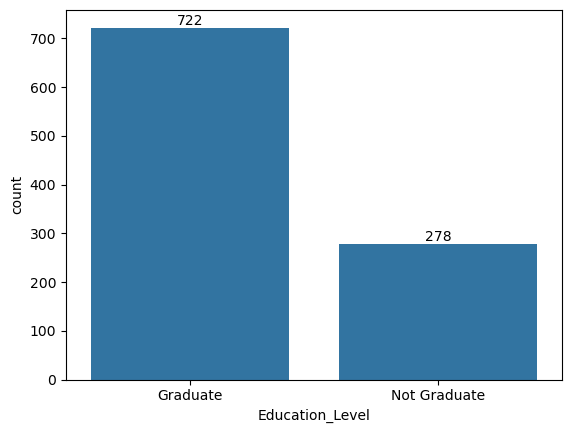

In [8]:
# categorical plot
edu_cnt = data["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

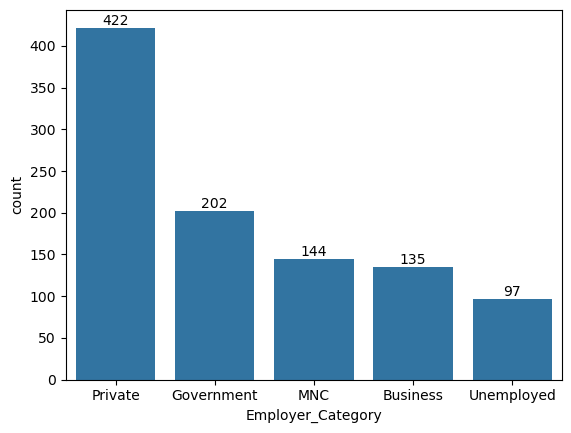

In [9]:
# Employer_Category
emp_cnt = data["Employer_Category"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

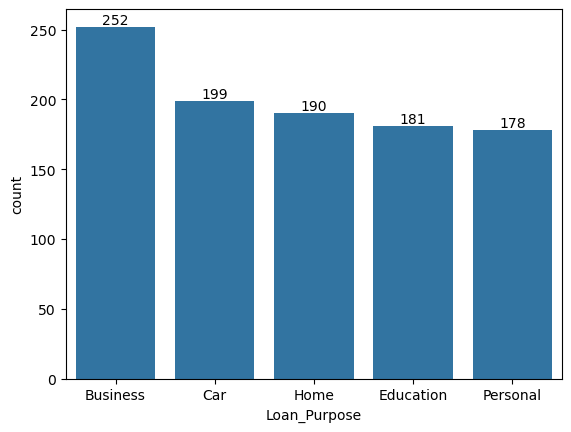

In [10]:
# Loan_Purpose
Loan_Purpose = data["Loan_Purpose"].value_counts()
ax = sns.barplot(Loan_Purpose)
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

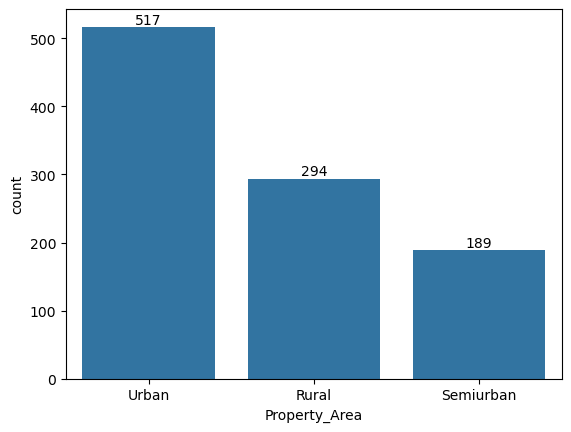

In [11]:
# Property_Area
Property_Area = data["Property_Area"].value_counts()
ax = sns.barplot(Property_Area)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

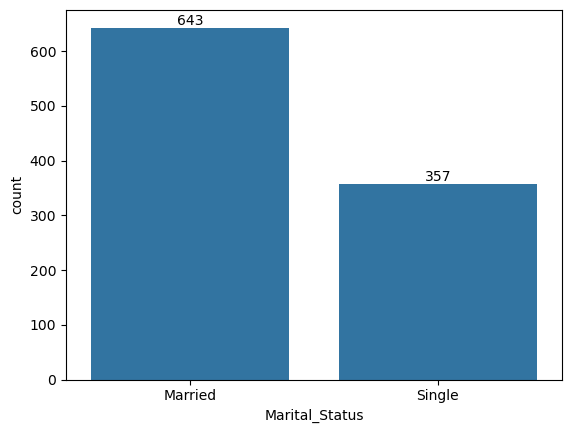

In [12]:
# Marital_Status
Marital_Status = data["Marital_Status"].value_counts()
ax = sns.barplot(Marital_Status)
ax.bar_label(ax.containers[0])

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

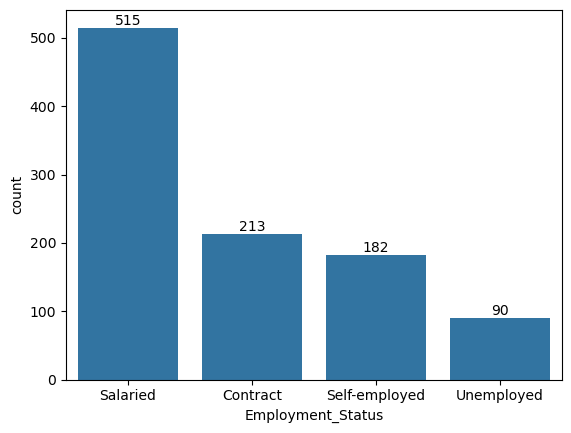

In [13]:
# Employment_Status
Employment_Status = data["Employment_Status"].value_counts()
ax = sns.barplot(Employment_Status)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

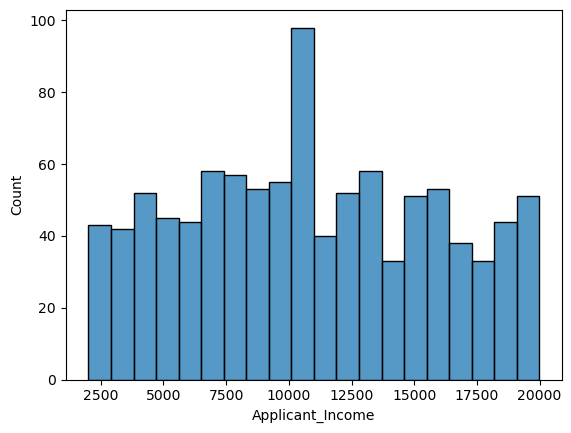

In [14]:
# analyze income
sns.histplot(
    data=data,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

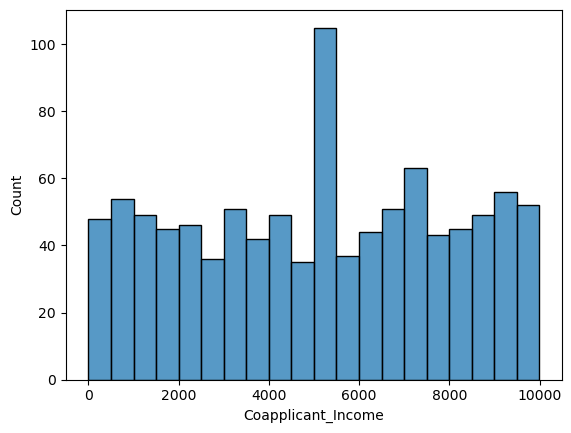

In [15]:
# analyze Coapplicant_Income
sns.histplot(
    data=data,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

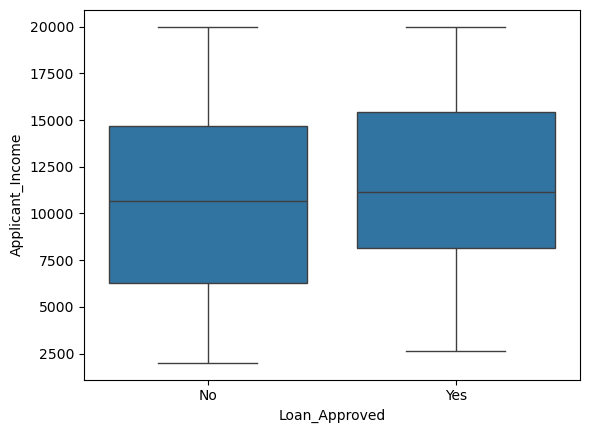

In [16]:
# Detect outlayer
sns.boxplot(x="Loan_Approved", y="Applicant_Income", data=data)

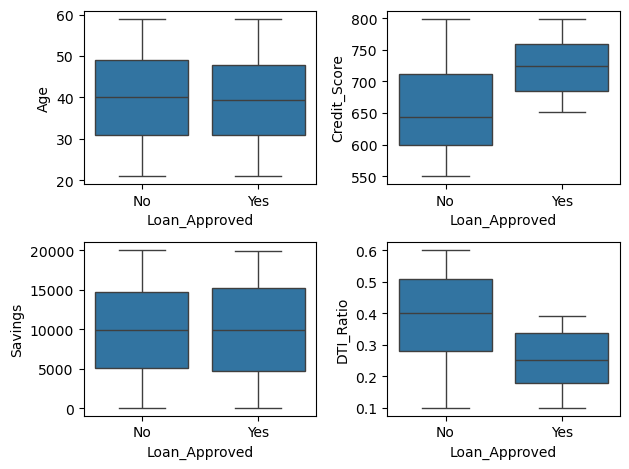

In [17]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],x="Loan_Approved", y="Age", data=data)
sns.boxplot(ax = axes[0,1],x="Loan_Approved", y="Credit_Score", data=data)
sns.boxplot(ax = axes[1,0],x="Loan_Approved", y="Savings", data=data)
sns.boxplot(ax = axes[1,1],x="Loan_Approved", y="DTI_Ratio", data=data)
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

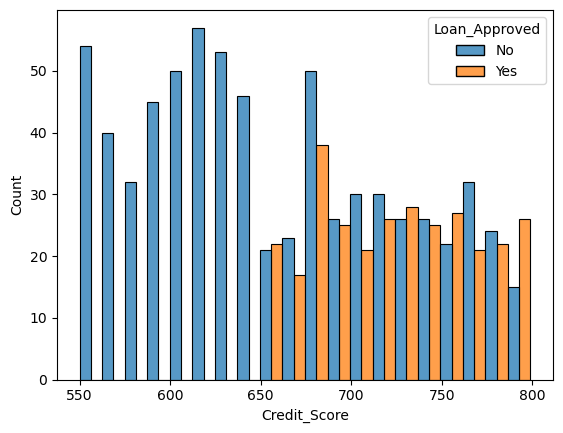

In [18]:
# Loan Approval
sns.histplot(
    data=data,
    x="Credit_Score",
    hue ="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [19]:
data = data.drop("Applicant_ID", axis=1)

# Encoding

In [20]:
le = LabelEncoder()
data["Education_Level"] = le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])

In [21]:
cls= ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(data[cls])

In [22]:
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cls),index=data.index)

In [23]:
df = pd.concat([data.drop(columns=cls),encoded_df],axis=1)

<Axes: >

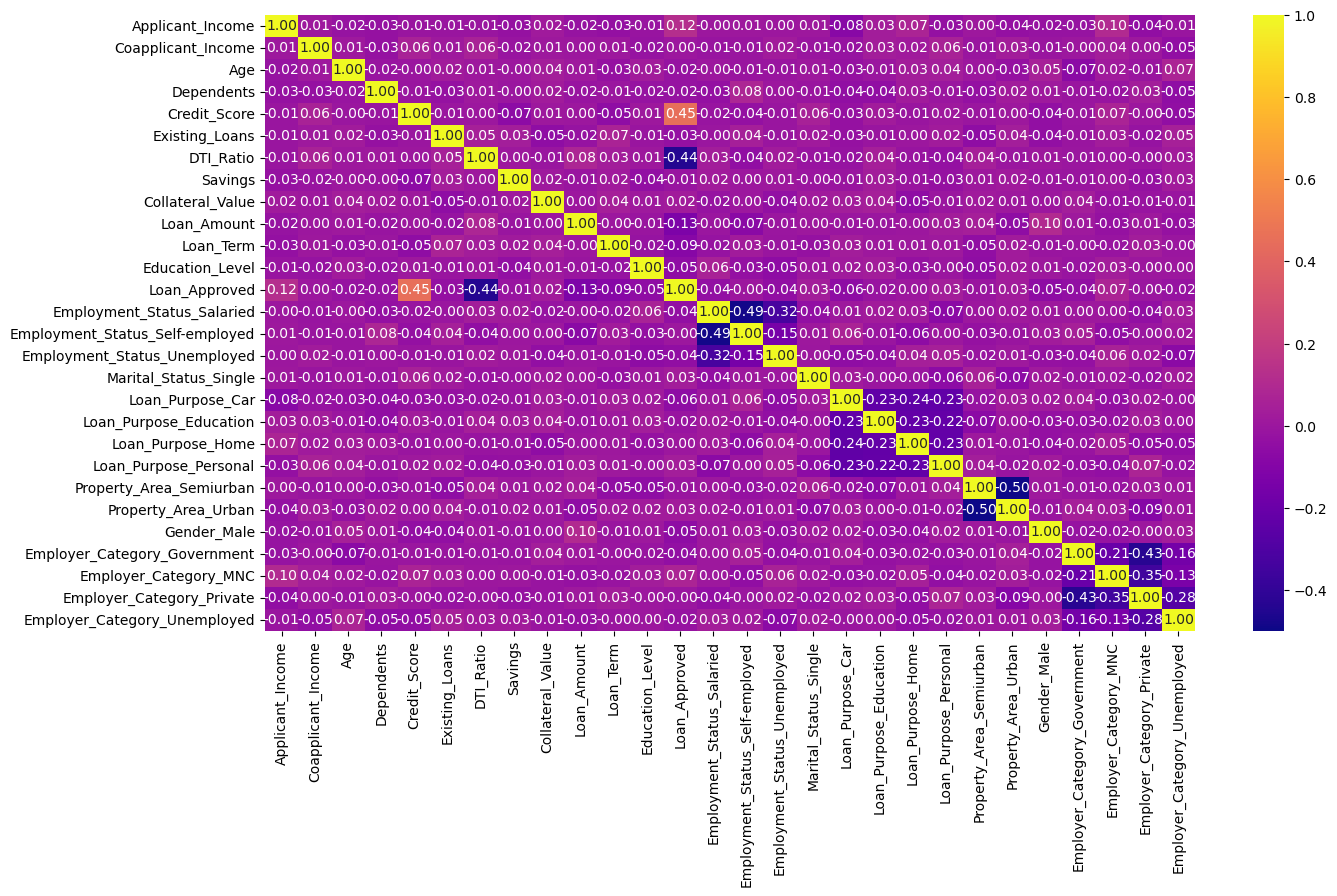

In [24]:
num_cols = df.select_dtypes(include="number")
corr_metrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_metrix,
    annot=True,
    fmt=".2f",
    cmap="plasma"
)

# Train-test-split + Feature Scalinbg

In [25]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [26]:
x_train, x_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [27]:
scaled = StandardScaler()

x_train_scaled = scaled.fit_transform(x_train)
x_test_scaled = scaled.transform(x_test)

# Model train & Evolution

In [28]:
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

y_pred = model.predict(x_test_scaled)

# Evaluatoin
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("F1: ",f1_score(y_test,y_pred))
print("confusion: ",confusion_matrix(y_test,y_pred))

precision:  0.7833333333333333
recall:  0.7704918032786885
accuracy:  0.865
F1:  0.7768595041322314
confusion:  [[126  13]
 [ 14  47]]


In [29]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train_scaled,y_train)

y_pred = model.predict(x_test_scaled)

# Evaluatoin
# Evaluatoin
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("F1: ",f1_score(y_test,y_pred))
print("confusion: ",confusion_matrix(y_test,y_pred))

precision:  0.6274509803921569
recall:  0.5245901639344263
accuracy:  0.76
F1:  0.5714285714285714
confusion:  [[120  19]
 [ 29  32]]


In [30]:
model = GaussianNB()
model.fit(x_train_scaled,y_train)

y_pred = model.predict(x_test_scaled)

# Evaluatoin
# Evaluatoin
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("F1: ",f1_score(y_test,y_pred))
print("confusion: ",confusion_matrix(y_test,y_pred))

precision:  0.8035714285714286
recall:  0.7377049180327869
accuracy:  0.865
F1:  0.7692307692307693
confusion:  [[128  11]
 [ 16  45]]
